In [104]:
import csv
import numpy as np
import matplotlib.pyplot as plt

In [105]:
xml_file = "../data/antoine/plateforme/test4.xml"
csv_gait_file = "../data/antoine/plateforme/test4/gait-line.csv"


In [106]:
import xml.etree.ElementTree as ET

def get_begin_time(xml_filepath_filenam):
    tree = ET.parse(xml_filepath_filenam)
    root = tree.getroot()

    # définir le namespace
    ns = {"z": "http://www.zebris.de/measurements"}

    # trouver la valeur de begin
    begin = root.find(".//z:clip/z:begin", ns)

    if begin is not None:
        return float(begin.text)
    return 0

print(get_begin_time(xml_file))

-10.15


In [107]:
def get_gait_samples(csv_file):
    times = []
    xs = []
    ys = []

    with open(csv_file, newline='', encoding="utf-8") as csvfile:
        reader = list(csv.reader(csvfile))

        # ---- Lire le nombre de lignes de données (count) ----
        count = int(reader[1][5])  # 6e élément de la 2e ligne

        # ---- Les données commencent à la ligne 5 (index 4) ----
        start_line = 4
        end_line = start_line + count

        for row in reader[start_line:end_line]:
            time = float(row[0])
            x = float(row[1])
            y = float(row[2])
            
            times.append(time)
            xs.append(x)
            ys.append(y)
        
        return np.array(times), np.array(xs), np.array(ys)


In [108]:
begin_time = get_begin_time(xml_file)
times, x_pos, y_pos = get_gait_samples(csv_gait_file)


In [109]:
times = times + begin_time

positive_time = np.where(times > 0)
times = times[positive_time]
x_pos = x_pos[positive_time]
y_pos = y_pos[positive_time]

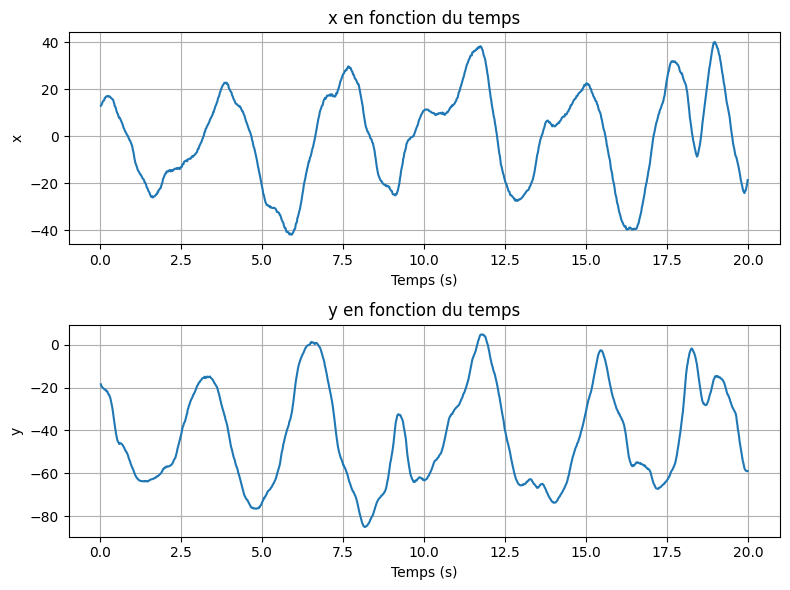

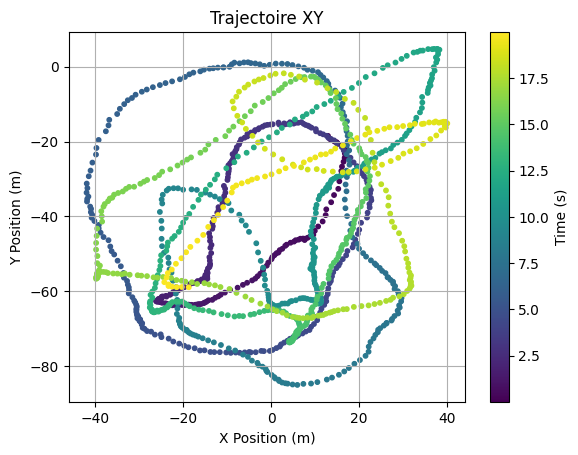

In [110]:
# ---- Plot X(t) et Y(t) ----
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(times, x_pos)
plt.xlabel("Temps (s)")
plt.ylabel("x")
plt.title("x en fonction du temps")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(times, y_pos)
plt.xlabel("Temps (s)")
plt.ylabel("y")
plt.title("y en fonction du temps")
plt.grid(True)

plt.tight_layout()
plt.show()


plt.figure()
sc = plt.scatter(x_pos, y_pos, c=times, cmap='viridis', s=10)
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()
